<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana3/ProbabilidadKDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Probabilidad en el rango [10, 15] (Segundo Pico):
- Histograma: 0.3850 (38.50%)
- KDE:        0.3786 (37.86%)
- Diferencia: 0.0064


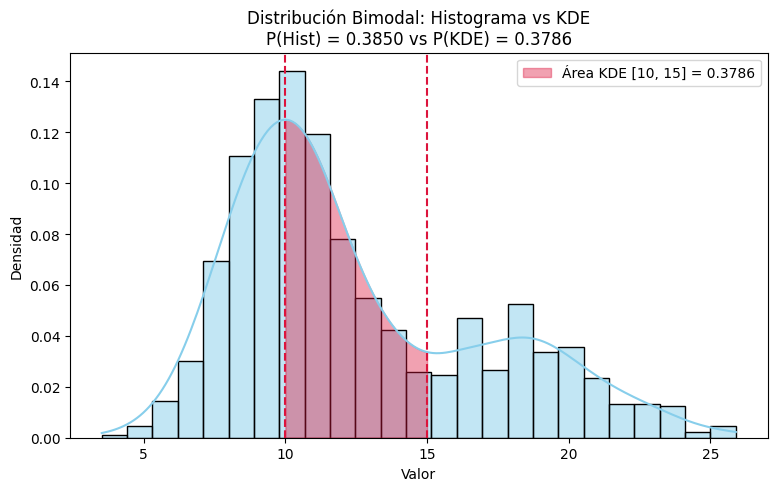

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import quad

# 1. Generar datos con DOS PICOS (Pico 1 alrededor de 10, Pico 2 alrededor de 18)
np.random.seed(42)
pico1 = np.random.normal(loc=10, scale=2, size=700)
pico2 = np.random.normal(loc=18, scale=3, size=300)
datos = np.concatenate([pico1, pico2])

# 2. Definir rango de interés [a, b] sobre el SEGUNDO PICO
a, b = 10, 15

# -------------------------------------------------------------
# 3. CÁLCULO DE PROBABILIDADES EN EL RANGO [15, 21]
# -------------------------------------------------------------

# A) Probabilidad con HISTOGRAMA (frecuencia relativa en el rango)
prob_hist = np.mean((datos >= a) & (datos <= b))

# B) Probabilidad con KDE (área integrada bajo la curva)
kde = gaussian_kde(datos)
prob_kde, _ = quad(kde.evaluate, a, b)

print(f"Probabilidad en el rango [{a}, {b}] (Segundo Pico):")
print(f"- Histograma: {prob_hist:.4f} ({prob_hist*100:.2f}%)")
print(f"- KDE:        {prob_kde:.4f} ({prob_kde*100:.2f}%)")
print(f"- Diferencia: {abs(prob_hist - prob_kde):.4f}")

# -------------------------------------------------------------
# 4. GRÁFICA EN JUPYTER
# -------------------------------------------------------------
plt.figure(figsize=(9, 5))

# Graficar Histograma + KDE
sns.histplot(datos, bins=25, stat="density", kde=True, color="skyblue")

# Sombrear el área del KDE en el segundo pico [15, 21]
x_area = np.linspace(a, b, 200)
plt.fill_between(x_area, kde.evaluate(x_area), color='crimson', alpha=0.4,
                 label=f'Área KDE [{a}, {b}] = {prob_kde:.4f}')

# Líneas verticales del intervalo
plt.axvline(a, color="crimson", linestyle="--", linewidth=1.5)
plt.axvline(b, color="crimson", linestyle="--", linewidth=1.5)

plt.title(f"Distribución Bimodal: Histograma vs KDE\nP(Hist) = {prob_hist:.4f} vs P(KDE) = {prob_kde:.4f}")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()
plt.show()

# Nueva sección